In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)


In [26]:
df = pd.read_csv("processed_breast cancer.csv")
#print first 5 rows 
print(df.head())

#print last 5 rows 
print("\n", df.tail())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  concavity_mean  concave points_mean  symmetry_mean  fractal_dimension_mean  radius_se  texture_se  perimeter_se  area_se  smoothness_se  compactness_se  concavity_se  concave points_se  symmetry_se  fractal_dimension_se  radius_worst  texture_worst  perimeter_worst  area_worst  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst
0          1        17.99         10.38          122.80     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871     1.0950      0.9053         8.589   153.40       0.006399         0.04904       0.05373            0.01587      0.03003              0.006193         25.38          17.33           184.60      2019.0            0.1622             0.6656           0.7119                0.2654          0.4601                  0.11890
1   

In [27]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


Accuracy Percentage : 97.37%
Precision : 0.98
Recall    : 0.95
F1-Score  : 0.96
confusion matrix for logistic regression
 [[70  1]
 [ 2 41]]


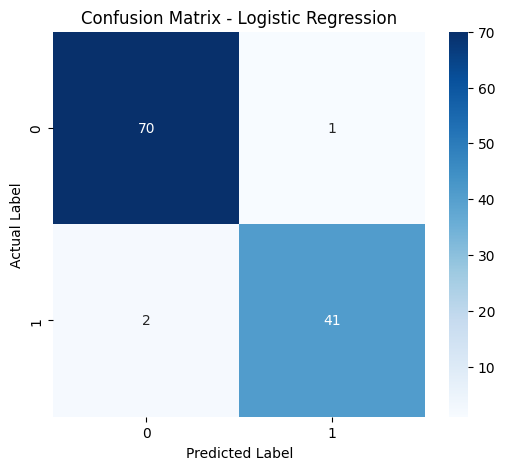

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC Score : 0.99737962659679


In [29]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

accuracy_lr=accuracy_score(y_test,y_pred_lr)
print(f"Accuracy Percentage : {accuracy_lr*100:.2f}%")

precision_lr=precision_score(y_test,y_pred_lr)
recall_lr=recall_score(y_test,y_pred_lr)
f1_lr=f1_score(y_test,y_pred_lr)
print(f"Precision : {precision_lr:.2f}")
print(f"Recall    : {recall_lr:.2f}")
print(f"F1-Score  : {f1_lr:.2f}")

lr_matrix=confusion_matrix(y_test,y_pred_lr)
print("confusion matrix for logistic regression\n",lr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(lr_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_lr))

y_prob_lr = lr.predict_proba( X_test_scaled)[:,1]
roc_lr= roc_auc_score(y_test,y_prob_lr)
print("ROC-AUC Score :", roc_lr)

In [ ]:
'''
Observation:-
- Accuracy: 97.37%
- Precision: 0.98
- Recall: 0.95
- F1-Score: 0.96
- ROC-AUC: 0.9974
'''

Accuracy Percentage : 94.74%
Precision : 0.93
Recall    : 0.93
F1-Score  : 0.93
confusion matrix for K-Nearest Neighbor 
 [[68  3]
 [ 3 40]]


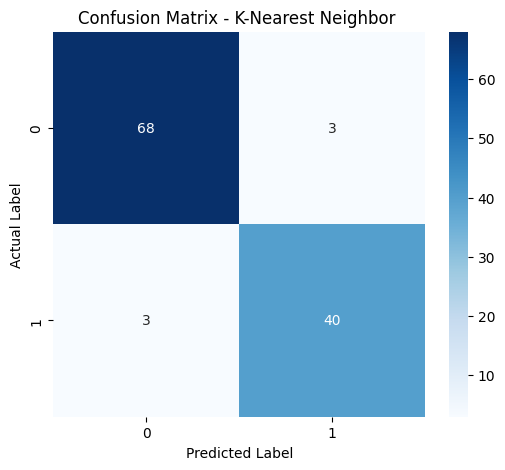

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

ROC-AUC Score : 0.9819849328529314


In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn=accuracy_score(y_test,y_pred_knn)
print(f"Accuracy Percentage : {accuracy_knn*100:.2f}%")

precision_knn=precision_score(y_test,y_pred_knn)
recall_knn=recall_score(y_test,y_pred_knn)
f1_knn=f1_score(y_test,y_pred_knn)
print(f"Precision : {precision_knn:.2f}")
print(f"Recall    : {recall_knn:.2f}")
print(f"F1-Score  : {f1_knn:.2f}")

knn_matrix=confusion_matrix(y_test,y_pred_knn)
print("confusion matrix for K-Nearest Neighbor \n",knn_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(knn_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - K-Nearest Neighbor ")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_knn))

y_prob_knn=knn.predict_proba( X_test_scaled)[:,1]
roc_knn= roc_auc_score(y_test,y_prob_knn)
print("ROC-AUC Score :", roc_knn)

In [ ]:
'''
Observation:-
- Accuracy: 94.74%
- Precision: 0.93
- Recall: 0.93
- F1-Score: 0.93
- ROC-AUC: 0.9820
'''

Accuracy Percentage : 98.25%
Precision : 1.00
Recall    : 0.95
F1-Score  : 0.98
confusion matrix for SVM 
 [[71  0]
 [ 2 41]]


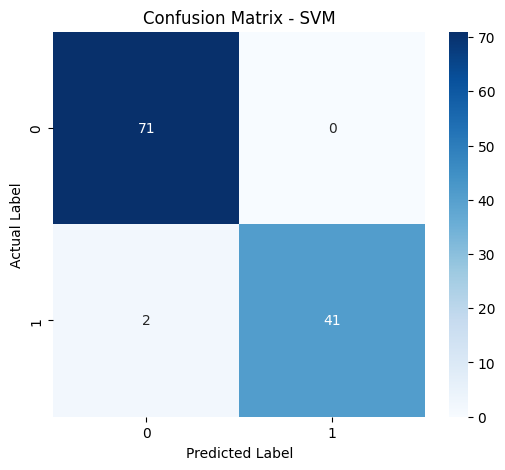

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC-AUC Score : 0.99737962659679


In [32]:
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

accuracy_svm=accuracy_score(y_test,y_pred_svm)
print(f"Accuracy Percentage : {accuracy_svm*100:.2f}%")

precision_svm=precision_score(y_test,y_pred_svm)
recall_svm=recall_score(y_test,y_pred_svm)
f1_svm=f1_score(y_test,y_pred_svm)
print(f"Precision : {precision_svm:.2f}")
print(f"Recall    : {recall_svm:.2f}")
print(f"F1-Score  : {f1_svm:.2f}")

svm_matrix=confusion_matrix(y_test,y_pred_svm)
print("confusion matrix for SVM \n",svm_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(svm_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_svm))

y_prob_svm=svm.predict_proba( X_test_scaled)[:,1]
roc_svm= roc_auc_score(y_test,y_prob_svm)
print("ROC-AUC Score :", roc_svm)

In [ ]:
'''
Observation:-
- Accuracy: 98.25%
- Precision: 1.00
- Recall: 0.95
- F1-Score: 0.98
- ROC-AUC: 0.9974
'''

Accuracy Percentage : 96.49%
Precision : 0.98
Recall    : 0.93
F1-Score  : 0.95
confusion matrix for Random Forest
 [[70  1]
 [ 3 40]]


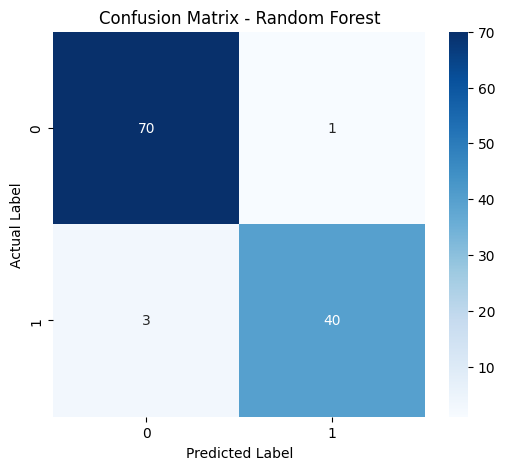

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC Score : 0.9952505732066819


In [33]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf=accuracy_score(y_test,y_pred_rf)
print(f"Accuracy Percentage : {accuracy_rf*100:.2f}%")

precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
print(f"Precision : {precision_rf:.2f}")
print(f"Recall    : {recall_rf:.2f}")
print(f"F1-Score  : {f1_rf:.2f}")

rf_matrix=confusion_matrix(y_test,y_pred_rf)
print("confusion matrix for Random Forest\n",rf_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(rf_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_rf))

y_prob_rf=rf.predict_proba( X_test)[:,1]
roc_rf= roc_auc_score(y_test,y_prob_rf)
print("ROC-AUC Score :", roc_rf)

In [ ]:
'''
Observation:-
- Accuracy: 96.49%
- Precision: 0.98
- Recall: 0.93
- F1-Score: 0.95
- ROC-AUC: 0.9953
'''

Accuracy Percentage : 96.49%
Precision : 0.98
Recall    : 0.93
F1-Score  : 0.95
Confusion Matrix for XGBoost
 [[70  1]
 [ 3 40]]


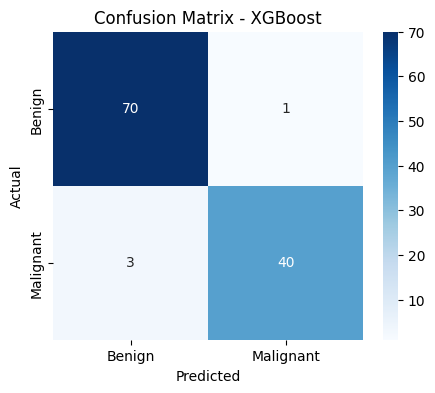

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC Score : 0.9934490664919751


In [36]:
xgb = XGBClassifier(random_state=42,eval_metric="logloss")
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

accuracy_xgb= accuracy_score(y_test, y_pred_xgb)
print("Accuracy Percentage : {:.2f}%".format(accuracy_xgb*100))

precision_xgb= precision_score(y_test, y_pred_xgb)
recall_xgb= recall_score(y_test, y_pred_xgb)
f1_xgb= f1_score(y_test, y_pred_xgb)
print("Precision :", round(precision_xgb,2))
print("Recall    :", round(recall_xgb,2))
print("F1-Score  :", round(f1_xgb,2))

cm_xgb= confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix for XGBoost\n", cm_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb,annot=True,fmt="d",cmap="Blues",xticklabels=["Benign","Malignant"],yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

print(classification_report(y_test, y_pred_xgb))

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC Score :", roc_xgb)

In [ ]:
'''
Observation:-
- Accuracy: 96.49%
- Precision: 0.98
- Recall: 0.93
- F1-Score: 0.95
- ROC-AUC: 0.9934
'''

In [37]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression","KNN","SVM","Random Forest","XGBoost"],
    "Accuracy": [accuracy_lr,accuracy_knn,accuracy_svm,accuracy_rf,accuracy_xgb],
    "Precision": [precision_lr,precision_knn,precision_svm,precision_rf,precision_xgb],
    "Recall": [recall_lr,recall_knn,recall_svm,recall_rf,recall_xgb],
    "F1-Score": [f1_lr,f1_knn,f1_svm,f1_rf,f1_xgb],
    "ROC-AUC": [roc_lr,roc_knn,roc_svm,roc_rf,roc_xgb]
})

comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.974,0.976,0.953,0.965,0.997
1,KNN,0.947,0.930,0.930,0.930,0.982
2,SVM,0.982,1.000,0.953,0.976,0.997
3,Random Forest,0.965,0.976,0.930,0.952,0.995
4,XGBoost,0.965,0.976,0.930,0.952,0.993


In [38]:
comparison.style.highlight_max(subset=["Accuracy", "F1-Score", "ROC-AUC"],color="pink")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.974000,0.976000,0.953000,0.965000,0.997000
1,KNN,0.947000,0.930000,0.930000,0.930000,0.982000
2,SVM,0.982000,1.000000,0.953000,0.976000,0.997000
3,Random Forest,0.965000,0.976000,0.930000,0.952000,0.995000
4,XGBoost,0.965000,0.976000,0.930000,0.952000,0.993000


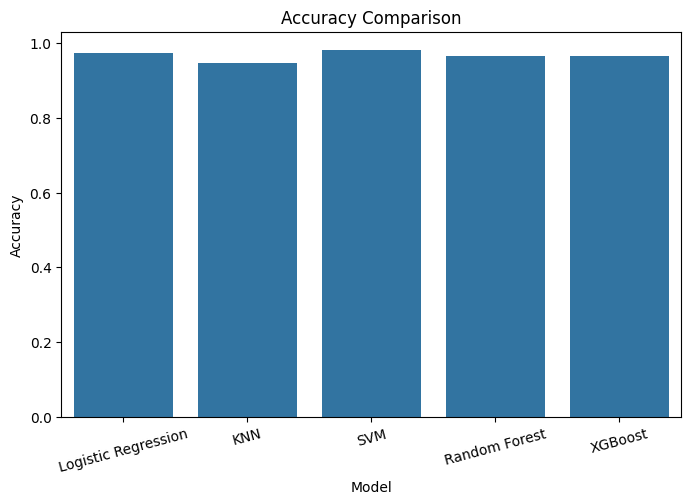

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)
plt.title("Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

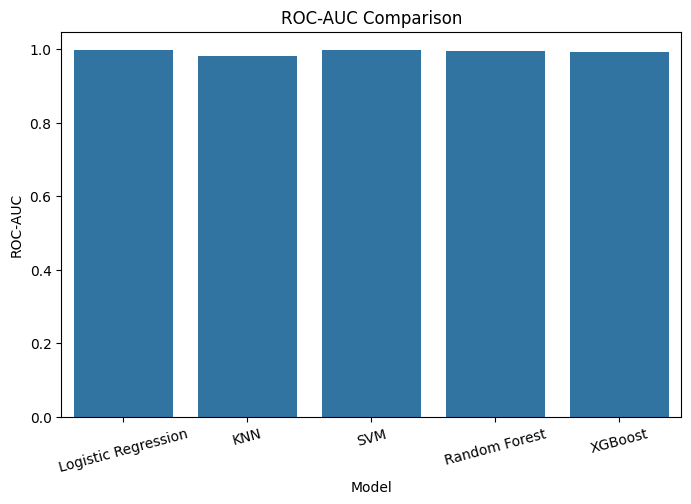

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="ROC-AUC",
    data=comparison
)
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.show()

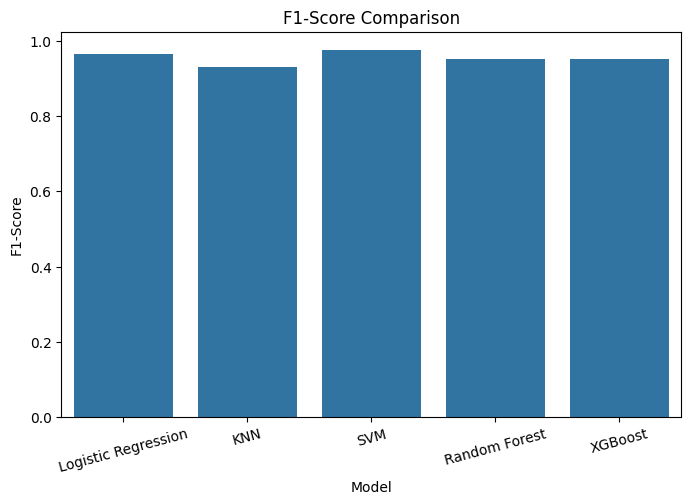

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="F1-Score",
    data=comparison
)
plt.title("F1-Score Comparison")
plt.xticks(rotation=15)
plt.show()

In [42]:
best_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]

print(f"Selected Model: {best_model}")

Selected Model: SVM


In [47]:
import joblib

joblib.dump(svm,r"E:\breast cancer disease prediction\models\svm_model.pkl")
joblib.dump(scaler, r"E:\breast cancer disease prediction\models\scaler.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
